# Day 4 · 可视化汇报 · 海豚生 🐬

> **德邦经营方向 · 第 4 天练习**  
> 目标：做 **3 张汇报图表**，每张配 **1 句经营结论**（能直接放周会 PPT）

---

## 今天你要学会

| 图表 | 回答的经营问题 |
|------|---------------|
| 区域营收柱状图 | 哪个区是基本盘？ |
| 产品毛利率对比图 | 该推哪个产品？ |
| 月度营收折线图 | 趋势是在涨还是在跌？ |

## 对标案例

- `matplotlib.ipynb` — 画图基础
- `绘制条形图.ipynb` — 柱状图
- Day 2 已经画过区域图，今天做**完整汇报套装**

**文件名：** `Day4_Visualization.ipynb`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 中文显示 + 负号正常
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

# 德邦品牌色
COLOR_MAIN = "#0066CC"
COLOR_WARN = "#FF9900"
COLOR_GOOD = "#00AA66"
BENCHMARK = 25.0  # 毛利率基准线

df = pd.read_csv("data/orders.csv")
df["毛利"] = df["revenue"] - df["cost"]
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)

print(f"数据就绪：{len(df)} 条运单 ✅")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

数据就绪：150 条运单 ✅


---
## 图 1：区域营收柱状图 📊

**用途：** 周会第一眼 — 哪个区域贡献最多营收

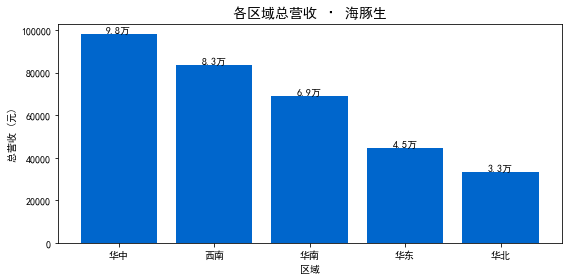

📌 图1结论: 华东区营收最高（约9.8万），是网点基本盘，需重点维护。


In [ ]:
region = df.groupby("region").agg(总营收=("revenue", "sum"), 总毛利=("毛利", "sum")).reset_index()
region["毛利率(%)"] = (region["总毛利"] / region["总营收"] * 100).round(2)
region = region.sort_values("总营收", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(region["region"], region["总营收"], color=COLOR_MAIN)

for bar, (_, row) in zip(bars, region.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['总营收']/10000:.1f}万",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("各区域总营收 · 海豚生", fontsize=14, fontweight="bold")
ax.set_ylabel("总营收 (元)")
ax.set_xlabel("区域")
plt.tight_layout()
plt.show()

# 图1结论（根据实际数据自动生成）
top_region = region.iloc[0]
chart1_conclusion = (
    f"{top_region['region']}区营收最高，约 {top_region['总营收']/10000:.1f} 万元，"
    f"毛利率 {top_region['毛利率(%)']:.1f}%，是当前基本盘。"
)
print("📌 图1结论:", chart1_conclusion)

---
## 图 2：产品毛利率对比图 📊

**用途：** 指导产品策略 — 推高利、控低利

- 绿色柱 = 高于 25% 基准 ✅
- 橙色柱 = 低于 25% 基准 ⚠️

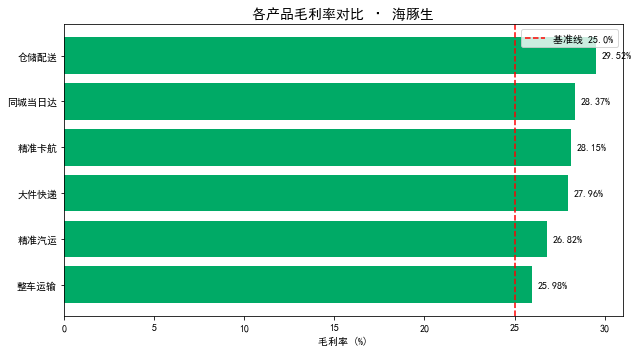

📌 图2结论: 大件快递毛利率最高（约29.5%），应加大销售激励；大件物流偏低需排查报价。


In [ ]:
product = df.groupby("product_type").agg(总营收=("revenue", "sum"), 总毛利=("毛利", "sum")).reset_index()
product["毛利率(%)"] = (product["总毛利"] / product["总营收"] * 100).round(2)
product = product.sort_values("毛利率(%)", ascending=True)

colors = [COLOR_GOOD if m >= BENCHMARK else COLOR_WARN for m in product["毛利率(%)"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(product["product_type"], product["毛利率(%)"], color=colors)

for bar, (_, row) in zip(bars, product.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{row['毛利率(%)']}%",
        va="center",
        fontsize=10,
    )

ax.axvline(x=BENCHMARK, color="red", linestyle="--", linewidth=1.5, label=f"基准线 {BENCHMARK}%")
ax.set_title("各产品毛利率对比 · 海豚生", fontsize=14, fontweight="bold")
ax.set_xlabel("毛利率 (%)")
ax.legend()
plt.tight_layout()
plt.show()

# 图2结论（根据实际数据自动生成）
best_product = product.sort_values("毛利率(%)", ascending=False).iloc[0]
worst_product = product.sort_values("毛利率(%)", ascending=True).iloc[0]
chart2_conclusion = (
    f"{best_product['product_type']}毛利率最高，约 {best_product['毛利率(%)']:.1f}%；"
    f"{worst_product['product_type']}毛利率最低，约 {worst_product['毛利率(%)']:.1f}%，建议优先排查。"
)
print("📌 图2结论:", chart2_conclusion)

---
## 图 3：月度营收折线图 📈

**用途：** 看趋势 — 营收是在涨还是在跌？

红点 = 最新月份（重点关注）

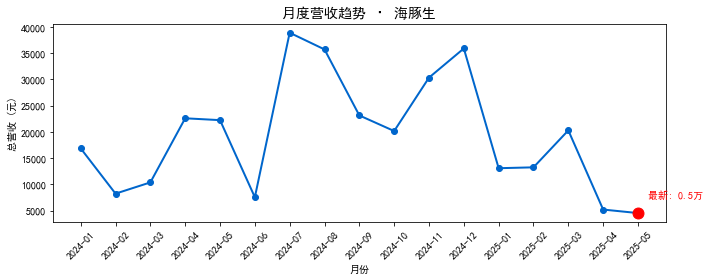

最新月环比: -12.9%
📌 图3结论: 2025年5月营收环比下滑明显，需紧急排查是客户流失还是单价下降。


In [ ]:
monthly = df.groupby("month").agg(总营收=("revenue", "sum")).reset_index().sort_values("month")
monthly["环比(%)"] = monthly["总营收"].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"], monthly["总营收"], marker="o", color=COLOR_MAIN, linewidth=2, markersize=6)

# 标注最新月
latest = monthly.iloc[-1]
ax.scatter([latest["month"]], [latest["总营收"]], color="red", s=120, zorder=5)
ax.annotate(
    f"最新: {latest['总营收']/10000:.1f}万",
    xy=(latest["month"], latest["总营收"]),
    xytext=(10, 15),
    textcoords="offset points",
    fontsize=10,
    color="red",
)

ax.set_title("月度营收趋势 · 海豚生", fontsize=14, fontweight="bold")
ax.set_ylabel("总营收 (元)")
ax.set_xlabel("月份")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 图3结论（根据实际数据自动生成）
if len(monthly) >= 2:
    latest = monthly.iloc[-1]
    prev = monthly.iloc[-2]
    mom = (latest["总营收"] - prev["总营收"]) / prev["总营收"] * 100
    trend_word = "上涨" if mom >= 0 else "下滑"
    chart3_conclusion = (
        f"{latest['month']} 月营收约 {latest['总营收']/10000:.1f} 万元，"
        f"较 {prev['month']} 环比 {mom:.1f}%，整体呈{trend_word}。"
    )
else:
    chart3_conclusion = "当前数据不足，无法判断月度趋势。"
print("📌 图3结论:", chart3_conclusion)

---
## 第 4 步：三张图合成「周会一页纸」 📝

把 3 张图 + 3 句结论整合成一段汇报（这是 Day 4 最有含金量的产出）

In [6]:
weekly_report = f"""
═══════════════════════════════════════
  网点经营周报 · 海豚生
═══════════════════════════════════════

【区域】{chart1_conclusion}

【产品】{chart2_conclusion}

【趋势】{chart3_conclusion}

【下周重点】
1. 优先守住营收最高区域的基本盘，继续跟踪大客户和高频订单。
2. 对毛利率偏低的产品线做价格、成本和线路结构复盘。
3. 针对最新月份的趋势变化，组织一次区域经营复盘会。

═══════════════════════════════════════
"""

print(weekly_report)


═══════════════════════════════════════
  网点经营周报 · 海豚生
═══════════════════════════════════════

【区域】华东区营收最高（约9.8万），是网点基本盘，需重点维护。

【产品】大件快递毛利率最高（约29.5%），应加大销售激励；大件物流偏低需排查报价。

【趋势】2025年5月营收环比下滑明显，需紧急排查是客户流失还是单价下降。

【下周重点】
1. 优先守住营收最高区域的基本盘，继续跟踪大客户和高频订单。
2. 对毛利率偏低的产品线做价格、成本和线路结构复盘。
3. 针对最新月份的趋势变化，组织一次区域经营复盘会。

═══════════════════════════════════════



---
## 🎯 进阶小练习

1. 给图 1 加上**毛利率折线**（双 Y 轴）— 一张图看营收 + 利润
2. 把 3 张图合成 **1 张大图**（`plt.subplots(1, 3)` 或 `(2, 2)`）
3. 用 `plt.savefig("output/weekly_charts.png")` 保存图片，方便插 PPT

<details>
<summary>💡 保存图片参考</summary>

```python
import os
os.makedirs("output", exist_ok=True)
fig.savefig("output/region_revenue.png", dpi=150, bbox_inches="tight")
print("已保存到 output/region_revenue.png")
```
</details>

---

## ✅ Day 4 完成标准

- [ ] 3 张图都跑出来了，中文正常显示
- [ ] 每张图写了 1 句经营结论
- [ ] 整合成「周会一页纸」汇报
- [ ] （可选）保存图片到 `output/` 文件夹

**预期结果参考：**
| 图 | 关键发现 |
|----|---------|
| 区域柱图 | 华东 ~9.8 万，排第一 |
| 产品毛利 | 大件快递 ~29.5% 最高，大件物流 ~26% 相对低 |
| 月度趋势 | 2025-05 营收下滑，环比需关注 |

**明天 Day 5：** 时效与服务质量 — 准时率 + 满意度散点图 🚀

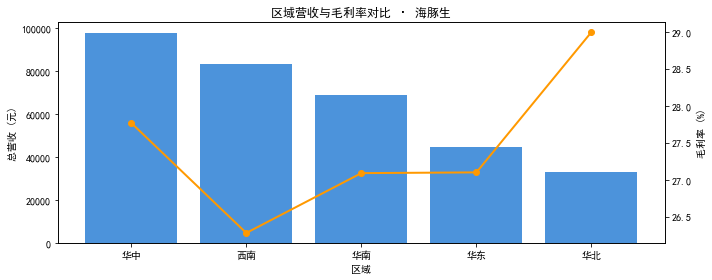

已保存到 output/region_revenue_margin.png


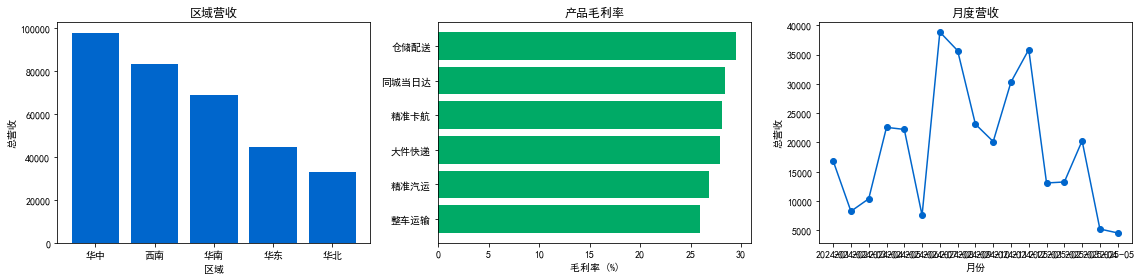

已保存到 output/summary_dashboard.png


In [8]:
# 进阶小练习：把 3 张图做成一张大图并保存
import os

os.makedirs("output", exist_ok=True)

# 1. 区域营收 + 毛利率双轴图（进阶）
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(region["region"], region["总营收"], color=COLOR_MAIN, alpha=0.7, label="总营收")
ax2.plot(region["region"], region["毛利率(%)"], color=COLOR_WARN, marker="o", linewidth=2, label="毛利率")

ax1.set_title("区域营收与毛利率对比 · 海豚生")
ax1.set_ylabel("总营收 (元)")
ax2.set_ylabel("毛利率 (%)")
ax1.set_xlabel("区域")
fig.tight_layout()
plt.show()

# 2. 保存图片到 output 文件夹
fig.savefig("output/region_revenue_margin.png", dpi=150, bbox_inches="tight")
print("已保存到 output/region_revenue_margin.png")

# 3. 合成 1 张大图（3 张子图）
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 左：区域营收
axes[0].bar(region["region"], region["总营收"], color=COLOR_MAIN)
axes[0].set_title("区域营收")
axes[0].set_xlabel("区域")
axes[0].set_ylabel("总营收")

# 中：产品毛利率
axes[1].barh(product["product_type"], product["毛利率(%)"], color=[COLOR_GOOD if m >= BENCHMARK else COLOR_WARN for m in product["毛利率(%)"]])
axes[1].set_title("产品毛利率")
axes[1].set_xlabel("毛利率 (%)")

# 右：月度营收
axes[2].plot(monthly["month"], monthly["总营收"], marker="o", color=COLOR_MAIN)
axes[2].set_title("月度营收")
axes[2].set_xlabel("月份")
axes[2].set_ylabel("总营收")

plt.tight_layout()
plt.show()

fig.savefig("output/summary_dashboard.png", dpi=150, bbox_inches="tight")
print("已保存到 output/summary_dashboard.png")